# <center><font color='green'>Desafío 3 - Predicción de churn</font></center>

1. Realizar un análisis exploratorio de los datos para comprender las características y la
distribución de los datos.

In [13]:
# Importamos las bibliotecas necesarías.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

# Creamos el dataframe usando 'pd.read_excel()'.
df= pd.read_excel('Telco-Customer-Churn.xlsx')

# Mostramos las primeras 4 filas el dataframe creado.
df.head(4)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No


In [2]:
# Vista general del dataset.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [3]:
df.shape

(7043, 21)

In [4]:
# Calidad de los datos.
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

array([[<Axes: title={'center': 'tenure'}>,
        <Axes: title={'center': 'MonthlyCharges'}>],
       [<Axes: title={'center': 'TotalCharges'}>, <Axes: >]], dtype=object)

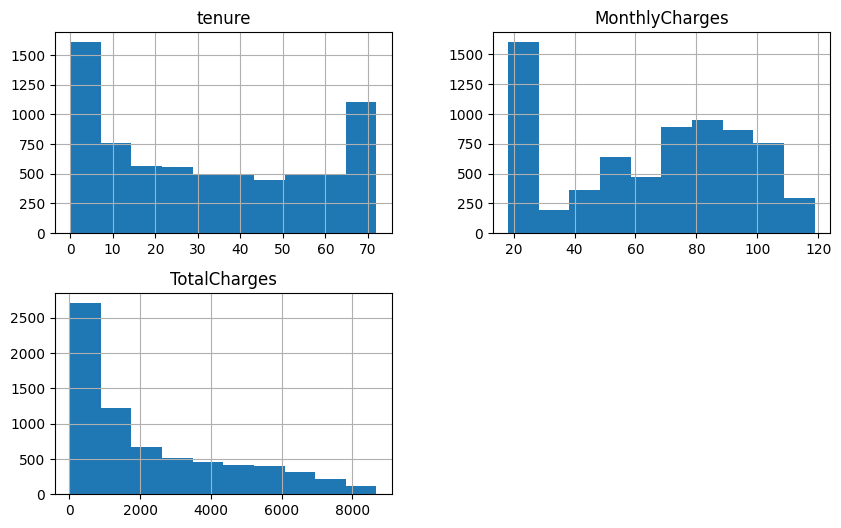

In [5]:
# Análisis de distribuciones.
df[['tenure','MonthlyCharges','TotalCharges']].hist(figsize=(10,6))

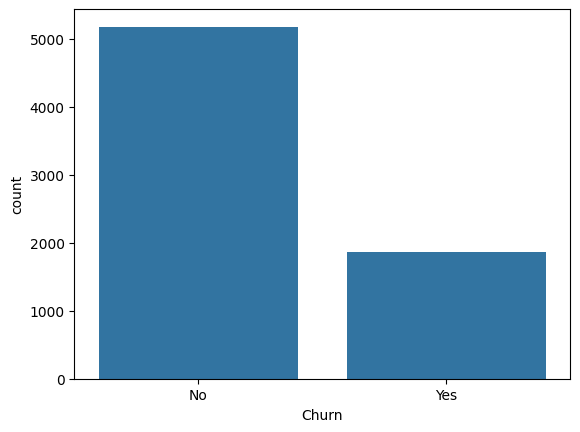

In [6]:
sns.countplot(x='Churn', data=df)
plt.show()

#### Comentarios:
  1. Descripción general del dataset:
El dataset contiene 7043 registros y 21 variables, que describen características de clientes de una empresa de telecomunicaciones.
  2. Calidad de los datos: No se detectan valores nulos en la mayoría de las variables. La variable TotalCharges presenta 11 valores faltantes. No se encontraron registros duplicados
  3. Tenure(antigüedad del cliente): Distribución dispersa. Se observan muchos clientes nuevos (valores bajos).También hay una concentración en valores altos (clientes antiguos).
  4. TotalCharges: Distribución sesgada a la derecha. Gran cantidad de valores bajos y pocos valores muy altos.
  5. MonthlyCharges: Mayor concentración en valores medios-altos.

2. Preprocesar los datos, incluyendo la limpieza, la transformación y la normalización
de las características según sea necesario.

In [7]:
# Eliminamos las filas con valores nulos.
df = df.dropna()

In [8]:
# Eliminamos customerID ya que no va ser útil en este análisis.
df.drop(columns=['customerID'], inplace=True)

In [9]:
# Tranformación de variables catagóricas a variables númericas.
df = pd.get_dummies(df, drop_first=True)

In [10]:
# Normalización. Vamos a escalar variables con el objetivo de mejorar el rendimiento de los modelos.

# Creamos el “objeto” que va a hacer la transformación.
scaler = StandardScaler()

df[['tenure','MonthlyCharges','TotalCharges']] = scaler.fit_transform(
    df[['tenure','MonthlyCharges','TotalCharges']]
)

3. Dividir los datos en conjuntos de entrenamiento y prueba.

In [11]:
# Variables predictoras (X) y objetivo (y).
X = df.drop('Churn_Yes', axis=1)
y = df['Churn_Yes']

In [12]:
# División train/test.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

4. Entrenar al menos 3 algoritmos y optimizar sus hiperparametros.

In [14]:
# Los modelos que vamos a usar son: KNN (K-Nearest Neighbors) y Árbol de Decisión.

# 1. KNN
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

param_knn = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance']
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_knn,
    cv=5,
    scoring='accuracy'
)

grid_knn.fit(X_train, y_train)

print(grid_knn.best_params_)

{'n_neighbors': 7, 'weights': 'uniform'}


In [15]:
# 2. Árbol de decisión
tree = DecisionTreeClassifier()
tree.fit(X_train, y_train)

param_tree = {
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5, 10]
}

grid_tree = GridSearchCV(
    DecisionTreeClassifier(),
    param_tree,
    cv=5
)

grid_tree.fit(X_train, y_train)

print(grid_tree.best_params_)

{'max_depth': 3, 'min_samples_split': 2}


#### Resultados de la optimización
La optimización de hiperparámetros permitió identificar las mejores configuraciones para cada modelo:
- KNN: Se determinó que el mejor desempeño se obtiene con 7 vecinos y ponderación uniforme, indicando que la clasificación se beneficia de considerar múltiples observaciones cercanas sin priorizar la distancia.
- Árbol de Decisión: El mejor modelo presenta una profundidad máxima de 3, lo que sugiere que una estructura simple es suficiente para capturar los patrones del dataset, reduciendo el riesgo de sobreajuste.

5. Evaluar el rendimiento de los modelos utilizando métricas de evaluación pertinentes,
como precisión, sensibilidad, valor F1, entre otras.

In [16]:
# Usando los mejores modelos:
y_pred_knn = grid_knn.best_estimator_.predict(X_test)
y_pred_tree = grid_tree.best_estimator_.predict(X_test)

In [17]:
# Calculamos las métricas:
print("KNN")
print(classification_report(y_test, y_pred_knn))

print("Árbol de decisión")
print(classification_report(y_test, y_pred_tree))

KNN
              precision    recall  f1-score   support

       False       0.84      0.84      0.84      1033
        True       0.56      0.56      0.56       374

    accuracy                           0.77      1407
   macro avg       0.70      0.70      0.70      1407
weighted avg       0.77      0.77      0.77      1407

Árbol de decisión
              precision    recall  f1-score   support

       False       0.81      0.92      0.86      1033
        True       0.66      0.40      0.50       374

    accuracy                           0.78      1407
   macro avg       0.73      0.66      0.68      1407
weighted avg       0.77      0.78      0.77      1407



#### Interpretación de resultados:
Dado que el objetivo es identificar clientes que abandonan el servicio (Churn = True), el análisis se centró en las métricas correspondientes a esta clase.
- El modelo KNN presenta un mejor equilibrio, con precisión de 0.56, recall de 0.56 y F1-score de 0.56, logrando detectar una proporción moderada de clientes que abandonan.
- Por otro lado, el Árbol de Decisión muestra una mayor precisión (0.66), pero un recall considerablemente menor (0.40) y un F1-score de 0.50, lo que indica que no logra identificar una parte importante de los clientes en riesgo de abandono.
- Si bien el Árbol de Decisión alcanza una accuracy ligeramente superior (0.78 vs 0.77), esta métrica resulta poco representativa debido al desbalance del dataset (1033 casos False frente a 374 True).

En conclusión, KNN resulta el modelo más adecuado, ya que ofrece un mejor balance entre precisión y recall, permitiendo identificar más clientes en riesgo en comparación con el Árbol de Decisión.